## Loading & Pre-Processing Data

#### 1. Importing the Images

The first dataset, from Kaggle, consists of about 8,000 samples of solar flares

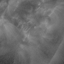

In [52]:
import os
import numpy as np

from PIL import Image
import matplotlib.pyplot as plt

IMG = 64

def load_gray(path):
    img = Image.open(path).resize((IMG, IMG))
    return img

img1 = load_gray('data\\training\\11388\\2012_01_07_02_27_01_0\\2012-01-06T142701__94.jpg')
display(img1)

### Loading a Set of Images
This function loads a set of images from the dataset. Giving it a sample number will return the target (peak emission) and the relevant images. If images are missing, they will be null with a flag.

In [ ]:
import os
import pandas as pd

from PIL import Image
import matplotlib.pyplot as plt

IMG = 24

# ----------------------------------------------------------------------
# STEP 3 — Turn each single image into many via data augmentation
# ----------------------------------------------------------------------
def augment(pil_img):
    """Return one randomly transformed 28x28 array in [0, 1]."""
    angle = np.random.uniform(-25, 25)                 # random rotation
    im = pil_img.rotate(angle, resample=Image.BILINEAR, fillcolor=0)
    # random shift
    dx, dy = np.random.randint(-3, 4), np.random.randint(-3, 4)
    im = im.transform((IMG, IMG), Image.AFFINE, (1, 0, dx, 0, 1, dy), fillcolor=0)
    arr = np.array(im, dtype=np.float32) / 255.0
    arr += np.random.normal(0, 0.06, arr.shape)        # random noise
    return np.clip(arr, 0, 1)

def build(pil_img, label, n):
    X = np.array([augment(pil_img) for _ in range(n)], dtype=np.float32)
    y = np.full((n, 1), label, dtype=np.float32)
    return X, y



def load_gray(path):
    img = Image.open(path).resize((IMG, IMG))
    return img

def find_folder(root_dir, folder_name):
    for root, dirs, files in os.walk(root_dir):
        if folder_name in dirs:
            return os.path.join(root, folder_name)
    
    return None

    
# Either 94, 131, 171, 193, 211, 304, 335, 1700, continuum, or magnetogram
SOURCE_TYPE = "magnetogram"

# Threshold of what the model considers a solar flare.
# C-Class (10e-6 - 10e-5): Limited effects on Earth
# M-Class (10e-5 - 10e-4): Can cause radio blackouts near poles
# X-Class (>10e-4): Can cause large radio blackouts & big problems

FLARE_THRESHOLD = 1e-5


def load_image_set(sample_id):

    # Get the data directory
    data_dir = find_folder("data", str(sample_id))

    # Get all the relevant files
    relevant_files = []
    for root, dirs, files in os.walk(data_dir):
        relevant_files = [os.path.join(root, f) for f in files if SOURCE_TYPE in f]

    # Load all relevant images
    X_list = []
    y_list = []

    # Determine whether this was a solar flare
    metadata = pd.read_csv(
        os.path.join(os.path.dirname(data_dir), "meta_data.csv")
    )    

    flux = 0
    for index, row in metadata.iterrows():
        if str(sample_id) in row["id"]:
            flux = row["peak_flux"]
            break
            

    # Go through and process all the images
    for file in relevant_files:
        curr_img = load_gray(file)
        display(curr_img)
        curr_X, curr_y = build(curr_img, flux > FLARE_THRESHOLD, 200)
        X_list.append(curr_X)
        y_list.append(curr_y)

    return X_list, y_list

# Use this to get the most relevant image
X_list, y_list = load_image_set(12106)
X_augmented = X_list[0][3]
y = y_list[3]
